<a href="https://colab.research.google.com/github/hosseinrezaie0/CI---T.A---Dr.Soltani/blob/main/Project_CV_Tutor_C5S2_Model_Training_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLO11s — Deer Detection Training

End-to-end training of `yolo11s` on the Roboflow *deer* dataset with sane
augmentation, a short hyperparameter search, and validation. Built for Google
Colab (GPU runtime). Set **Runtime → Change runtime type → GPU** first.

## 1. Install dependencies

In [1]:
%pip install -q roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 3.2 MB/s eta 0:00:00


## 2. Environment check
Confirm a GPU is actually attached before training.

In [2]:
import torch
from google.colab import userdata
from ultralytics import YOLO
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
assert torch.cuda.is_available(), "No GPU — set Runtime > Change runtime type > GPU"
print(torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
torch 2.11.0+cu128 | CUDA: True
Tesla T4


## 3. Download the dataset

Paste your Roboflow API key below. `dataset.location` gives the extracted
folder path, so we never hardcode `/content/deer-*` (the version suffix
changes and breaks the path otherwise).

In [3]:
from roboflow import Roboflow
API_KEY = userdata.get("API_KEY")
rf = Roboflow(api_key=API_KEY)  # <-- your key here
project = rf.workspace("humberto-x8knm").project("deer-ufhb0-nidon")
version = project.version(2)
dataset = version.download("yolov11")

DATA_YAML = f"{dataset.location}/data.yaml"
print("data.yaml:", DATA_YAML)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Deer-2 in yolov11:: 100%|██████████| 405/405 [00:00<00:00, 743.77it/s]


data.yaml: /content/Deer-2/data.yaml


## 4. Inspect the dataset
Sanity-check classes and split sizes before spending GPU time.

In [4]:
import yaml, glob, os

with open(DATA_YAML) as f:
    d = yaml.safe_load(f)
print("classes:", d["names"])

root = dataset.location
for split in ["train", "valid", "test"]:
    imgs = glob.glob(f"{root}/{split}/images/*")
    if imgs:
        print(f"{split:6s}: {len(imgs)} images")

classes: ['Deer']
train : 140 images
valid : 30 images
test  : 30 images


## 5. Load the model

Start from COCO-pretrained `yolo11s.pt` (transfer learning — far better than
scratch on a small dataset).

In [5]:
model = YOLO("yolo11s.pt")

## 6. Hyperparameter tuning (optional, GPU-heavy)

`model.tune()` runs a genetic search over LR / momentum / augmentation
strengths and writes the best combo to `tune/best_hyperparameters.yaml`.
Skip if you're short on time — the defaults in step 7 are already solid.

In [6]:
import torch
from ultralytics import YOLO

torch.cuda.empty_cache()

model = YOLO("yolo11s.pt")

# Combine stable optimizer bounds with your selected augmentations
search_space = {
    # --- Optimizer Stability (keep these to prevent NaN loss) ---
    "lr0": (1e-4, 1e-3),
    "lrf": (0.01, 0.1),
    "momentum": (0.8, 0.95),
    "weight_decay": (0.0, 0.001),
    # --- Target Augmentations ---
    "hsv_h": (0.0, 0.05),  # Hue shift (drone/trail cam foliage & lighting)
    "hsv_s": (0.0, 0.8),  # Saturation
    "hsv_v": (0.0, 0.8),  # Brightness / exposure
    "degrees": (0.0, 45.0),  # Orientation rotation
    "translate": (0.0, 0.4),  # Translation / shift
    "scale": (0.1, 0.8),  # Zoom variation (drone altitude / trail distance)
    "fliplr": (0.0, 1.0),  # Horizontal flip probability
    "mosaic": (0.0, 1.0),  # Mosaic probability
    "close_mosaic": (1, 5),  # Disable mosaic in final N epochs
}

model.tune(
    data=DATA_YAML,
    epochs=5,
    iterations=10,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    optimizer="AdamW",
    space=search_space,
    # --- Hard-disable unwanted augmentations ---
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    bgr=0.0,
    mixup=0.0,
    cutmix=0.0,
    copy_paste=0.0,
    plots=True,
    save=False,
    val=True,
)

Tuner: Initialized Tuner instance with 'tune_dir=/content/runs/detect/tune'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/10 with hyperparameters: {'lr0': 0.001, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'fliplr': 0.5, 'mosaic': 1.0, 'close_mosaic': 5}
Saved /content/runs/detect/tune/tune_scatter_plots.png
Saved /content/runs/detect/tune/tune_fitness.png

Tuner: 1/10 iterations complete ✅ (93.19s)
Tuner: Results saved to /content/runs/detect/tune
Tuner: Best fitness=0.34161 observed at iteration 1
Tuner: Best fitness metrics are {'metrics/precision(B)': 0.52887, 'metrics/recall(B)': 0.8, 'metrics/mAP50(B)': 0.62536, 'metrics/mAP50-95(B)': 0.34161, 'val/box_loss': 1.22899, 'val/cls_loss': 9.00734, 'val/dfl_loss': 1.96462, 'fitness': 0.34161}
Tuner: Best fitness model is /content/runs/detect/tune/weights
Printing 

## 7. Train

Best practices baked in:
- **Transfer learning** from COCO weights.
- **Augmentation**: mosaic + HSV + flips + modest rotate/scale/translate,
  plus a little mixup/cutmix for occlusion robustness. `close_mosaic=10`
  turns mosaic off for the final epochs so the model settles on real images.
- **`cos_lr`** cosine schedule + warmup, **AdamW**, **AMP** for speed.
- **`patience=25`** early-stopping so we don't overfit a small set.
- **`cache=True`** to keep the dataset in RAM between epochs.

Tune the augmentation knobs to your data: if the camera viewpoint is fixed
(e.g. fixed drone angle), drop `degrees`/`perspective` toward 0.

In [11]:
import torch

torch.cuda.empty_cache()

results = model.train(
    data=DATA_YAML,
    cfg="/content/runs/detect/tune/best_hyperparameters.yaml",  # loads tuned lr, momentum, augmentations, etc.
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    patience=15,
    cos_lr=True,
    amp=True,
    cache=True,
    seed=42,
    project="deer_yolo11s",
    name="run1_tuned",
    exist_ok=True,
    plots=True,
)

print("best weights:", model.trainer.best)

Ultralytics 8.4.122 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=/content/runs/detect/tune/best_hyperparameters.yaml, channels_last=False, classes=None, close_mosaic=4, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Deer-2/data.yaml, degrees=0.00199, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.51158, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0143, hsv_s=0.70296, hsv_v=0.4761, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01148, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.88535, mos

In [12]:
print("best weights:", model.trainer.best)

best weights: /content/runs/detect/deer_yolo11s/run1_tuned/weights/best.pt


## 8. Validate
Metrics on the validation split (mAP50, mAP50-95, precision, recall).

In [13]:
metrics = model.val()
print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"mAP50-95 : {metrics.box.map:.4f}")

Ultralytics 8.4.122 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3177.6±1160.8 MB/s, size: 1217.5 KB)
val: Scanning /content/Deer-2/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 8.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.5s/it 3.0s
                   all         30         30       0.96      0.933       0.98      0.848
Speed: 8.3ms preprocess, 29.7ms inference, 0.5ms loss, 2.7ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP50    : 0.9796
mAP50-95 : 0.8475


## 9. Visualize training results

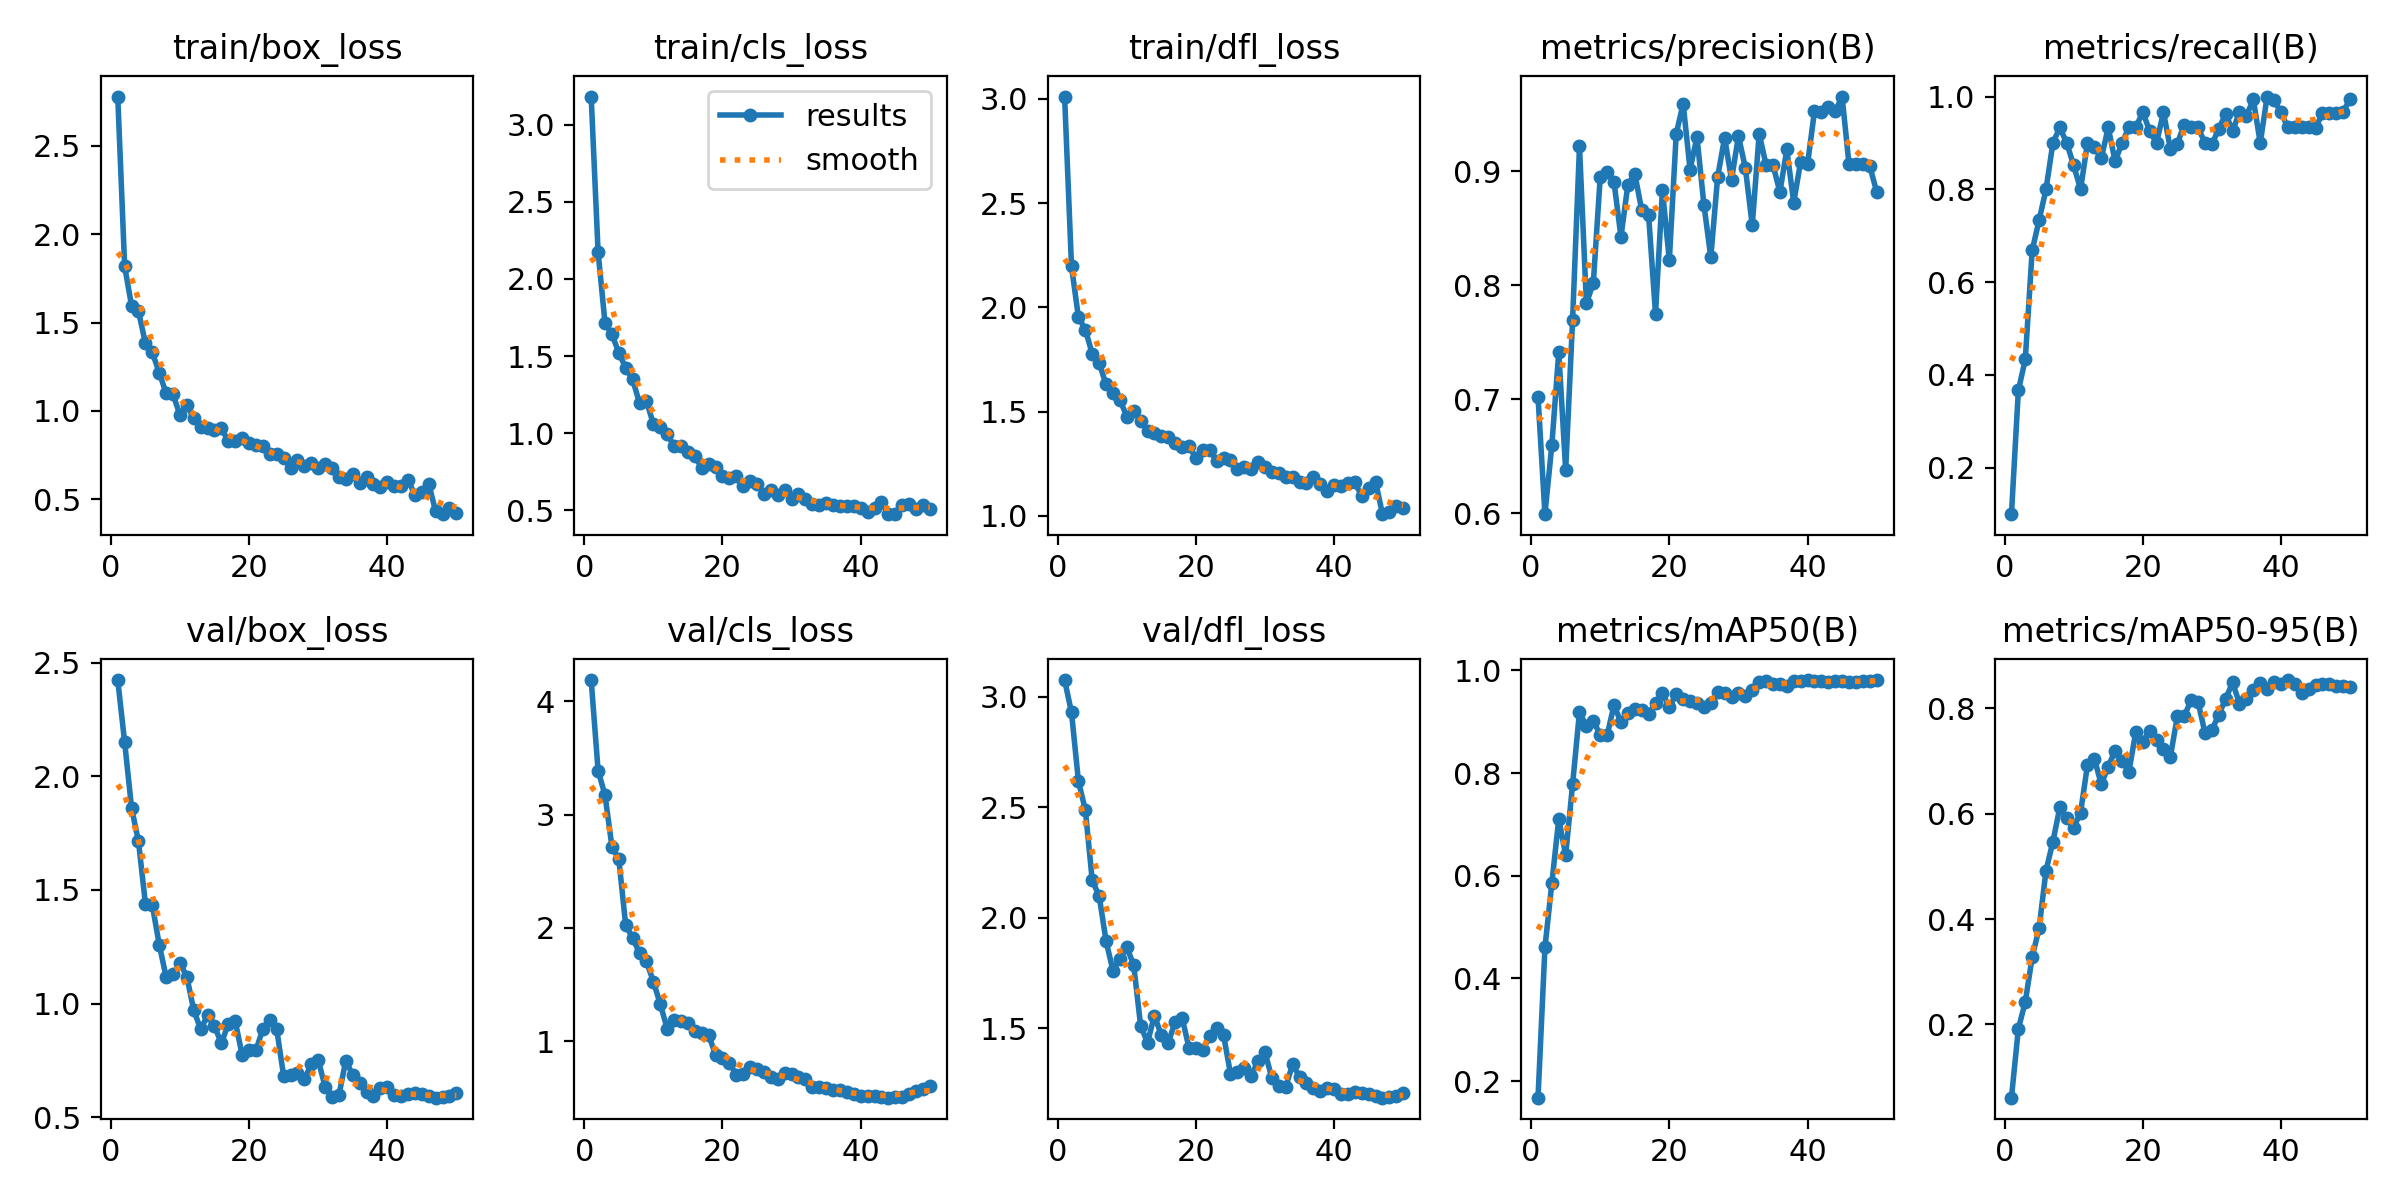

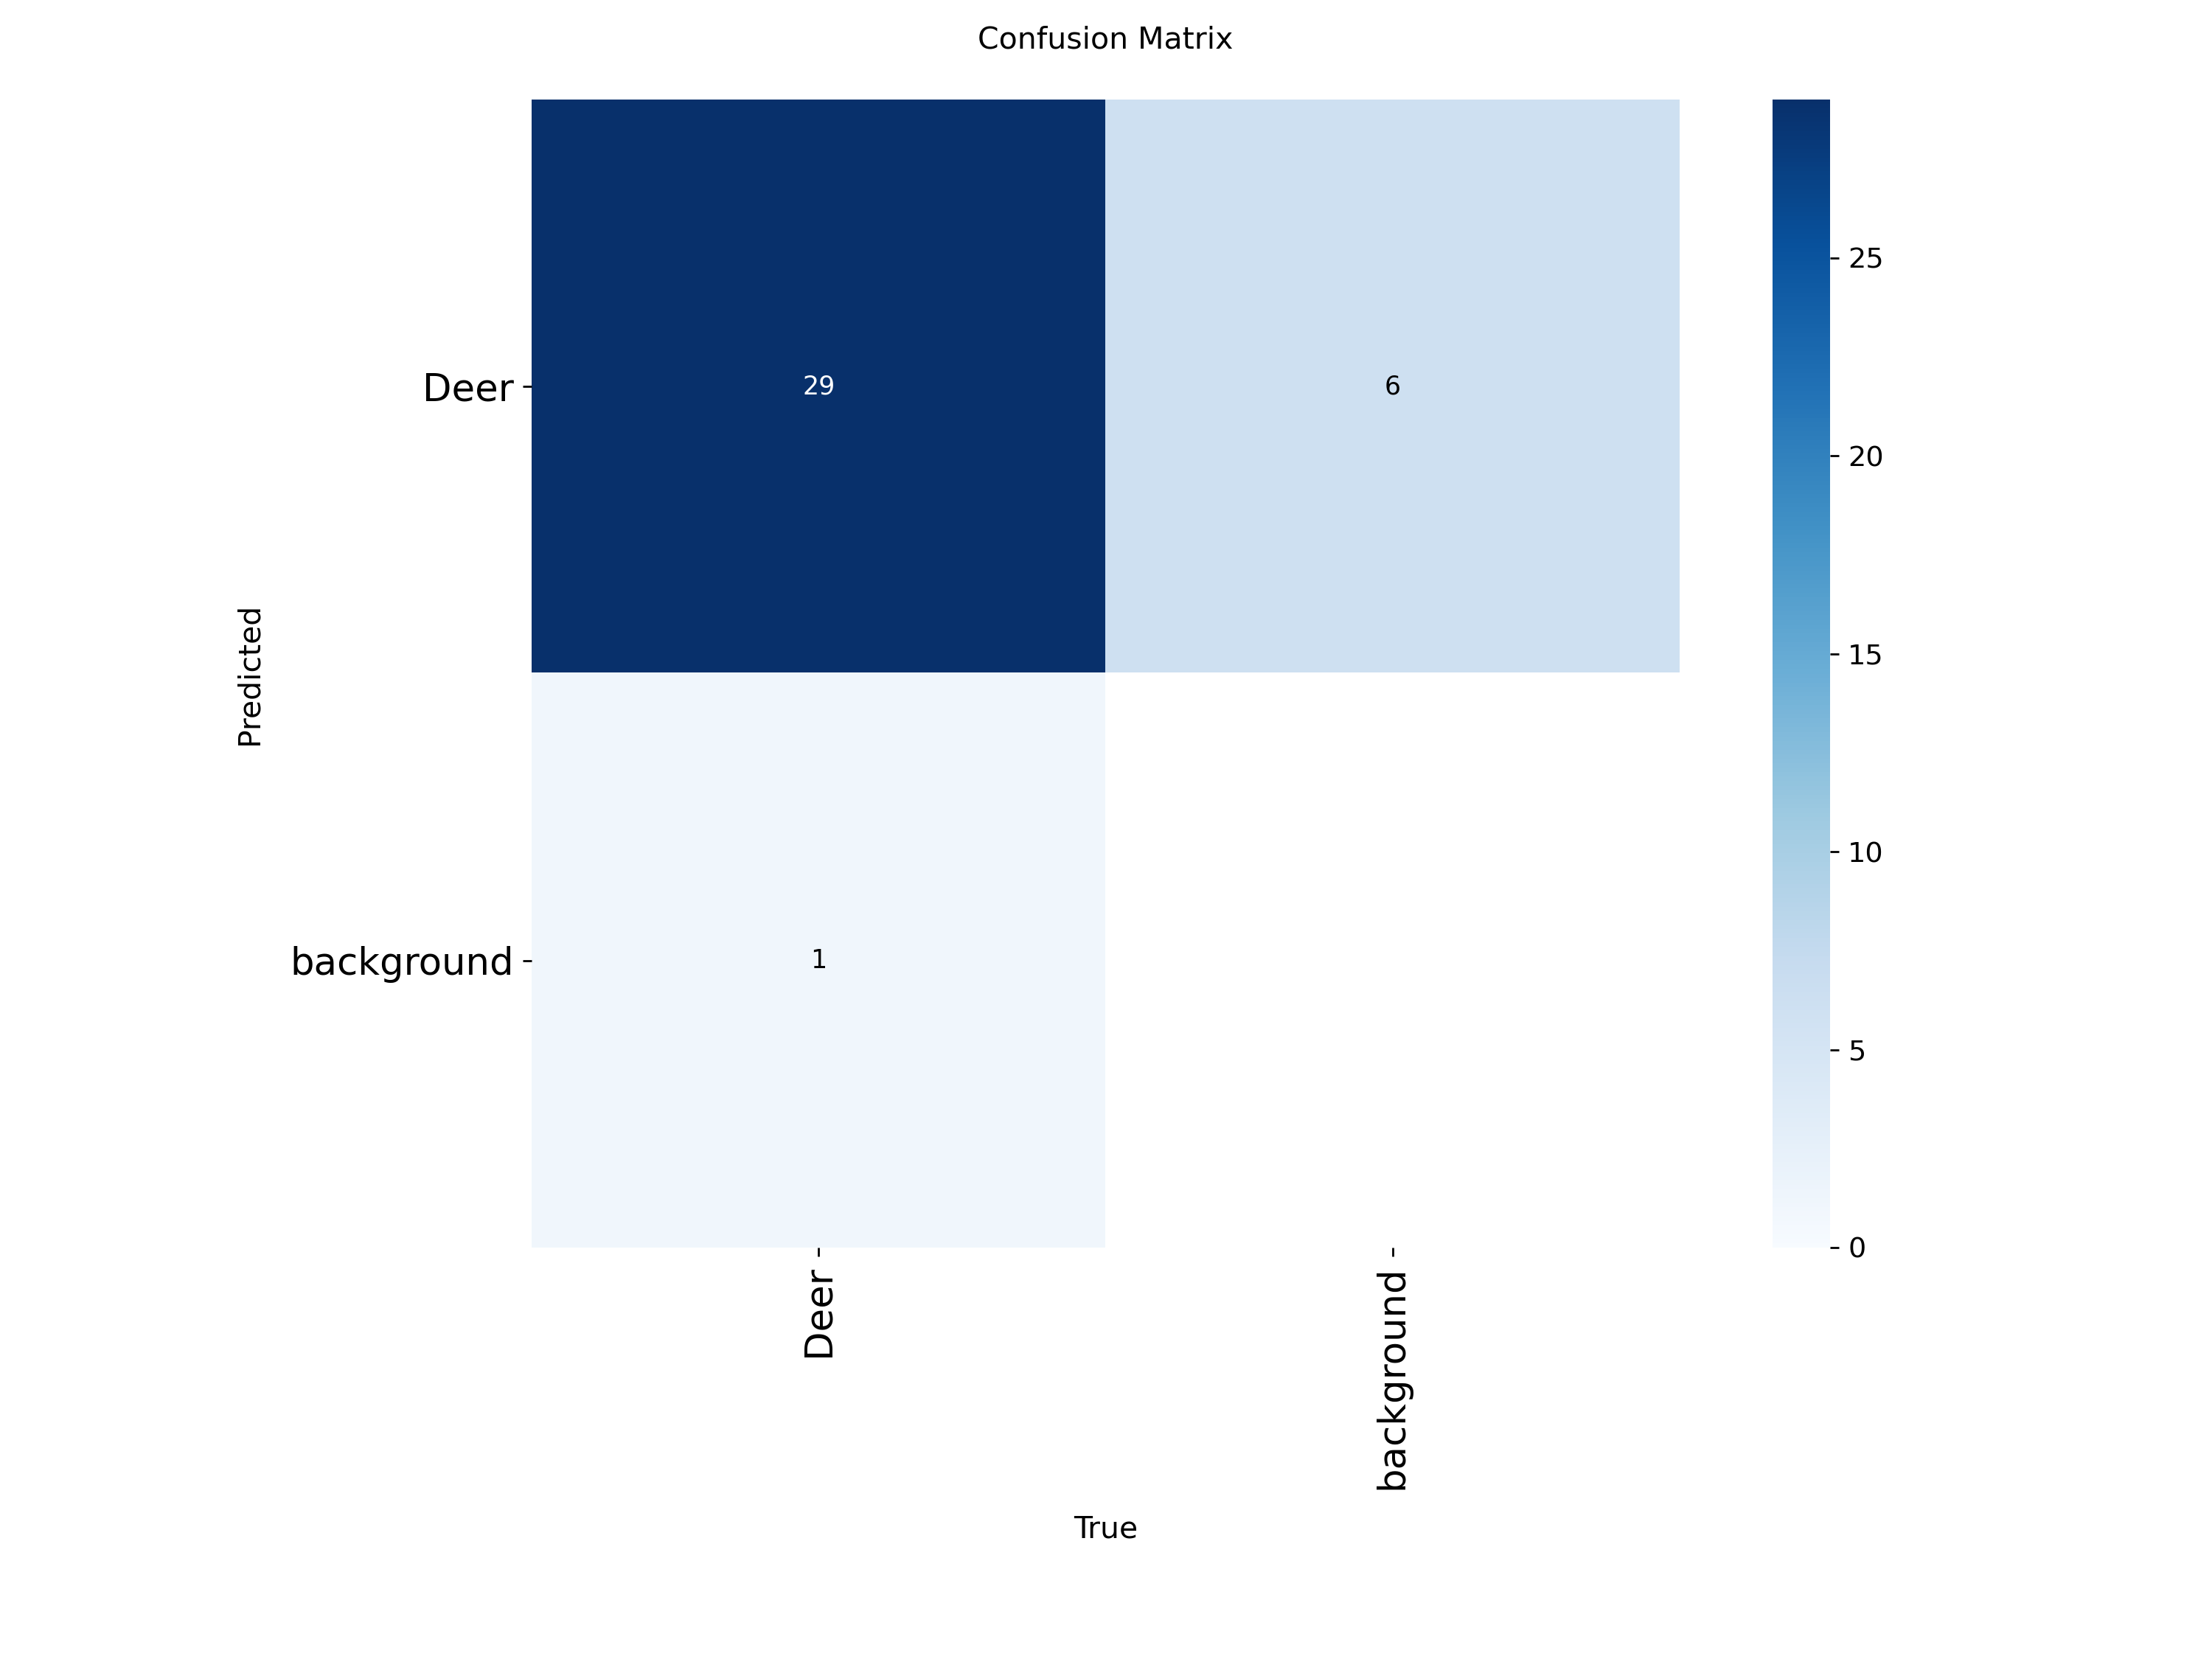

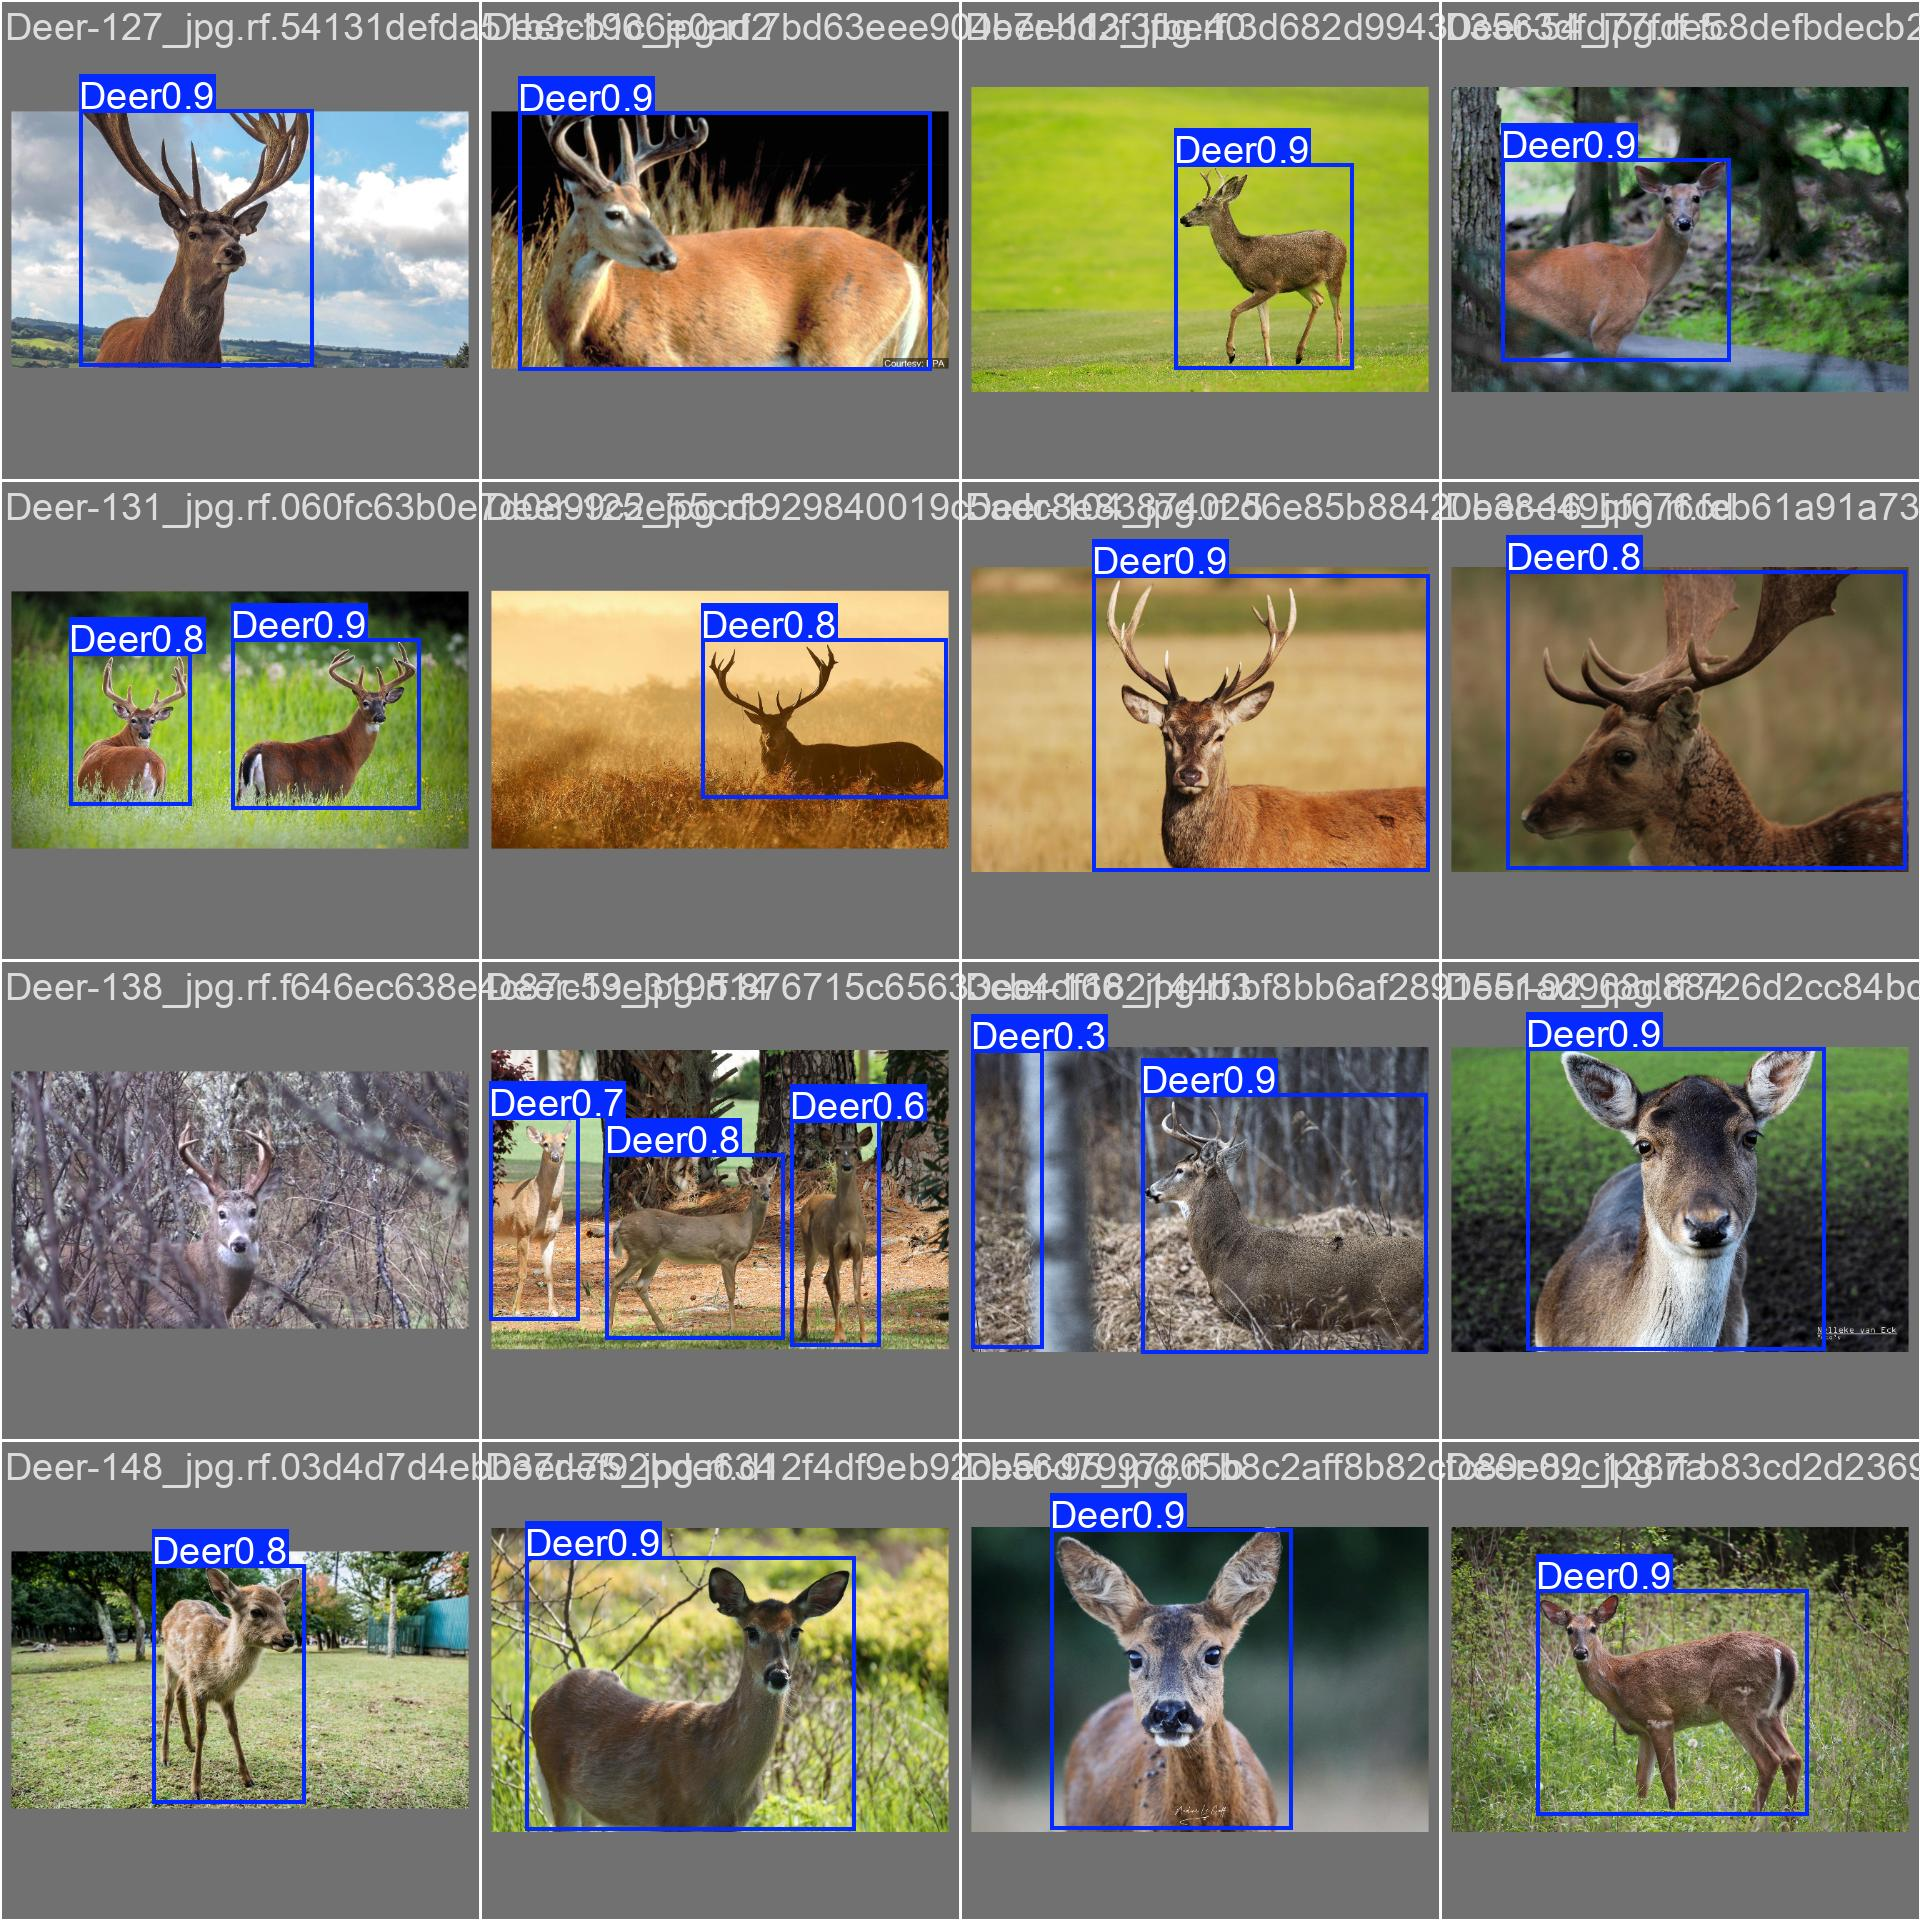

In [18]:
import os
from IPython.display import Image, display

run = "runs/detect/deer_yolo11s/run1_tuned"

for p in [f"{run}/results.png", f"{run}/confusion_matrix.png", f"{run}/val_batch0_pred.jpg"]:
    if os.path.exists(p):
        display(Image(filename=p, width=800))
    else:
        print(f"Not found: {p}")

## 10. Predict on a sample
Run the best weights over the test split (or point `source` at your own image/video).


0: 640x640 2 Deers, 12.0ms
1: 640x640 (no detections), 12.0ms
2: 640x640 1 Deer, 12.0ms
3: 640x640 1 Deer, 12.0ms
4: 640x640 1 Deer, 12.0ms
5: 640x640 1 Deer, 12.0ms
Speed: 2.2ms preprocess, 12.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


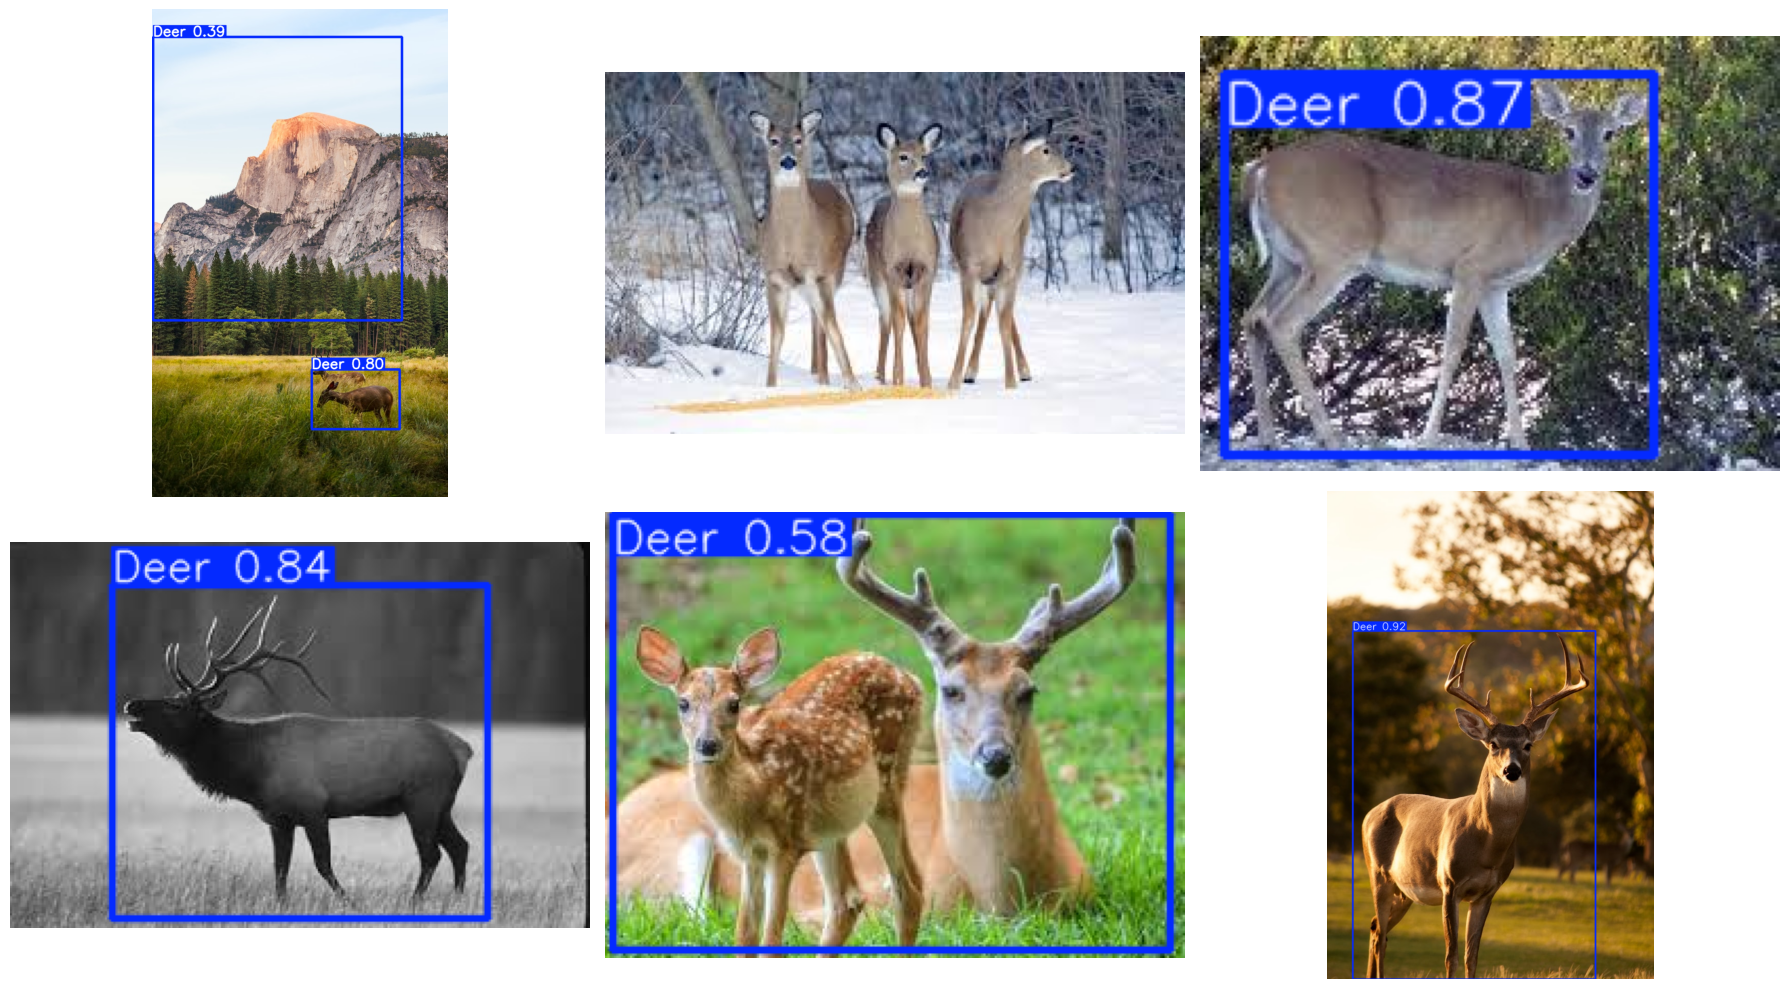

In [23]:
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load model
best = YOLO(model.trainer.best)

# 2. Get images from your folder (supports .jpg, .jpeg, .png)
image_paths = (
    glob.glob("/content/images/*.jpg")
    + glob.glob("/content/images/*.jpeg")
    + glob.glob("/content/images/*.png")
)[:6]  # Display up to 6 images

# 3. Run inference
results = best.predict(source=image_paths, conf=0.25)

# 4. Plot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, r in zip(axes, results):
    im_bgr = r.plot()
    im_rgb = im_bgr[..., ::-1]  # Convert BGR to RGB
    ax.imshow(im_rgb)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Export / download best weights

In [19]:
# best.pt is portable to detection, tracking (model.track), or ONNX export
print("Best weights at:", model.trainer.best)
# best.export(format="onnx")   # uncomment for deployment

try:
    from google.colab import files
    files.download(model.trainer.best)
except Exception as e:
    print("Not on Colab or download skipped:", e)

Best weights at: /content/runs/detect/deer_yolo11s/run1_tuned/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>